<a href="https://colab.research.google.com/github/edik06031-rgb/Analysis_Cafe_Sales-/blob/main/EDA_analysis_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analysis_Cafe_Sales**

Cafe Sales - Dirty Data for Cleaning Training

**Overview**


The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

File Information

* File Name: dirty_cafe_sales.csv

* Number of Rows: 10,000

* Number of Columns: 8

| Column Name | Description | Example Values |
| ----------- | ----------- | -------------- |
| `Transaction ID` | A unique identifier for each transaction. Always present and unique. | `TXN_1234567` |
| `Item` | The name of the item purchased. May contain missing or invalid values (e.g., "ERROR"). | `Coffee`, `Sandwich` |
| `Quantity` | The quantity of the item purchased. May contain missing or invalid values. | `1`, `3`, `UNKNOWN` |
| `Price Per Unit` | The price of a single unit of the item. May contain missing or invalid values. | `2.00`, `4.00` |
| `Total Spent` | The total amount spent on the transaction. Calculated as `Quantity * Price Per Unit`. | `8.00`, `12.00` |
| `Payment Method` | The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). | `Cash`, `Credit Card` |
| `Location` | The location where the transaction occurred. May contain missing or invalid values. | `In-store`, `Takeaway`
| `Transaction Date` | The date of the transaction. May contain missing or incorrect values. | `2023-01-01` |

Data Characteristics
Missing Values:

Some columns (e.g., Item, Payment Method, Location) may contain missing values represented as None or empty cells.
Invalid Values:

Some rows contain invalid entries like "ERROR" or "UNKNOWN" to simulate real-world data issues.
Price Consistency:

Prices for menu items are consistent but may have missing or incorrect values introduced.
Menu Items
The dataset includes the following menu items with their respective price ranges:

Item	Price($)
Coffee	2
Tea	1.5
Sandwich	4
Salad	5
Cake	3
Cookie	1
Smoothie	4
Juice	3
Use Cases
This dataset is suitable for:

Practicing data cleaning techniques such as handling missing values, removing duplicates, and correcting invalid entries.
Exploring EDA techniques like visualizations and summary statistics.
Performing feature engineering for machine learning workflows.
Cleaning Steps Suggestions
To clean this dataset, consider the following steps:

Handle Missing Values:

Fill missing numeric values with the median or mean.
Replace missing categorical values with the mode or "Unknown."
Handle Invalid Values:

Replace invalid entries like "ERROR" and "UNKNOWN" with NaN or appropriate values.
Date Consistency:

Ensure all dates are in a consistent format.
Fill missing dates with plausible values based on nearby records.
Feature Engineering:

Create new columns, such as Day of the Week or Transaction Month, for further analysis.


In [ ]:
!pip show numpy

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

!pip install numpy pandas matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [127]:
# File path
# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://raw.githubusercontent.com/edik06031-rgb/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

In [ ]:
#FILE_IN ='https://raw.githubusercontent.com/edik06031-rgb/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'
#FILE_OUT = 'cafe_sales_clean.csv'

In [ ]:

df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


# Download Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/edik06031-rgb/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'
df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
df = df_origin.copy()
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Primery Diagnosis

In [ ]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
print("Data types(raw):\n")
df.dtypes

Data types(raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns (Quantity,Price Per Unit,Total Spent)
- Date columns(Transaction Date)

Missing values

In [ ]:
print("Mission values: \n")
missing = df.isnull().sum()
missing_pct = (missing / len(df)* 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count']>0]

Mission values: 



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [ ]:
print("Unique values: \n")

print("--- Item ---\n")
print(df["Item"].value_counts(dropna=False))
#display(df["Item"].value_counts(dropna=False))


print("--- Payment Method ---\n")
print(df["Payment Method"].value_counts(dropna=False))


print("\n--- Location ---\n")
print(df["Location"].value_counts(dropna=False))
#display(df["Location"].value_counts(dropna=False))


Unique values: 

--- Item ---

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64
--- Payment Method ---

Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

--- Location ---

Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [ ]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
mask_error = df.isin(['ERROR','UNKNOWN']).any(axis=1)
#df.isin(['ERROR','UNKNOWN']).any()
print(f"\nlines with 'ERROR' or 'UNKNOWN' :{mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'


lines with 'ERROR' or 'UNKNOWN' :2845


DZ Замість True/False записати кількість error s unknown у кожному стовбчику

In [ ]:
print("Find lines  with 'ERROR' or 'UNKNOWN \n")

Find lines  with 'ERROR' or 'UNKNOWN 



# Data Cleaning

Якшо не зроблена копія датасету - тут необхідно створити!!!

df_origin - original dataset
df - copy original dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
"   Transaction Date   ".strip().lower().replace(" ","_")

'transaction_date'

In [ ]:
# df.columns.str.lower().str.split()

print("Rename columns:\n")

df.columns = df.columns.str.strip()
df = df.rename(columns= {
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [ ]:
"_".join("     Transaction   Date   ".lower().split())

'transaction_date'

In [ ]:
"   Transaction   Date   ".strip().lower().replace(" ", "_")

'transaction___date'

In [ ]:
"   Transaction Date   ".strip().lower().replace(" ", "_")

'transaction_date'

In [ ]:
# 'ERROR'/'UNKNOWN' -> Nan
df.replace(['ERROR','UNKNOWN','error','unknown', ''],np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
print(df.columns.tolist())

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [ ]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [ ]:
#df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
print('Converting columns:\n')

df.dtypes

Converting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [ ]:
# Extracring time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int64')
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int64')

df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


Наступний код не потрібен у проекті

In [ ]:
# new_df = pd.DataFrame({"quantity": [0, 3, 5, '', np.nan,"q"]})
# pd.to_numeric(new_df['quantity'], errors='coerce')

In [ ]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")


Restoring total_spent: 462 string (quantity * price) 


In [ ]:
# dict of median price

price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

df[58:59]

#mask_price.sum()

#df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string (mediana per item) ")

Restoring price_per_unit: 479 string (mediana per item) 


In [ ]:
type(df[mask_price])  # DataFrame
type(df[mask_price]['item'])  # Series
type(df[mask_price][['item', 'price_per_unit']])  # DataFrame

type(df.loc[mask_price, 'item'])  # Series
type(df.loc[mask_price, ['item', 'price_per_unit']])  # DataFrame


pandas.core.frame.DataFrame

In [ ]:
# Restoring total_spent (quantity * price)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (quantity * price) ")


Restoring total_spent: 17 string (quantity * price) 


In [ ]:
# fillna item -> mode
mode_item = df['item'].mode()[0]
#df['item'].fillna(mode_item, inplace=True)
df.fillna({'item': mode_item}, inplace=True)

In [ ]:
# delete Transaction date where Nat or NaN
befor = len(df)
df.dropna(subset = ['transaction_date','quantity'], inplace=True)
after = len(df)
print(f"Deleted {befor - after} rows")

Deleted 914 rows


In [ ]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [ ]:
# delete duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
(df.quantity <= 0).sum()  # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [ ]:
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [ ]:
(df['quantity'].isna()| df['price_per_unit'].isna()).sum()

np.int64(48)

In [ ]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [ ]:

df.dropna(subset=['total_spent'], inplace=True)
print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [ ]:
for col in ['item','payment_method','location']:
    df[col]= df[col].str.strip().str.title()
    print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)
Text fields are standartized (Title Case)
Text fields are standartized (Title Case)


In [ ]:
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
mask_total_spent.sum()
print(f"Uncorrect row total_spent :{mask_total_spent.sum()}")

Uncorrect row total_spent :0


In [ ]:
df.isna().sum()

,0
transaction_id,0
item,0
quantity,0
price_per_unit,0
total_spent,0
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [ ]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23


# Cleaning results

In [ ]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results: \n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin)*100:.1f}%)")

print("\nResidual gaps")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\nData types after cleanup:")
display(df.dtypes)
#print(df.dtypes)
print("\n--- Statistics ---")
print(df[['quantity','price_per_unit','total_spent']].describe().round(2))

#print(f"{}")
#print(f"{}")



Cleaning results: 

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

Residual gaps
No gaps

Data types after cleanup:


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int64
month,Int64



--- Statistics ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


# Feature Engineering

In [ ]:
#season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4:'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn',11: 'Autumn'

}
df['season'] = df['month'].map(season_map)
#df[[]]


In [ ]:
#Is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday','Sunday'])

In [ ]:
# check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low','Medium', 'High', 'Premium']
)


In [ ]:
print('New attribute : season, is_weekend. spend_tier')

New attribute : season, is_weekend. spend_tier


In [ ]:
#df['total_spent'].describe()
df[df['total_spent'] > 15]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown,2023-03-31,2023,3,March,Friday,13,Spring,False,High
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown,2023-10-28,2023,10,October,Saturday,43,Autumn,True,High
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown,In-Store,2023-12-31,2023,12,December,Sunday,52,Winter,True,High
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,45,Autumn,False,Premium
21,TXN_3567645,Smoothie,4.0,4.0,16.0,Credit Card,Takeaway,2023-03-30,2023,3,March,Thursday,13,Spring,False,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,TXN_6120851,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-02-04,2023,2,February,Saturday,5,Winter,True,Premium
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-Store,2023-07-20,2023,7,July,Thursday,29,Summer,False,High
9981,TXN_4583012,Juice,5.0,4.0,20.0,Digital Wallet,Unknown,2023-02-27,2023,2,February,Monday,9,Winter,False,High
9992,TXN_2739140,Smoothie,4.0,4.0,16.0,Unknown,In-Store,2023-07-05,2023,7,July,Wednesday,27,Summer,False,High


In [ ]:
[1, 5, 5, 7, 9, 10, 10, 10, 20]
low = [1, 5, 5]
midle = [7, 9, 10]
hight = [10, 10, 20]


In [ ]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20,Spring,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23,Summer,True,Low


# Fast EDA (verification graphs)

In [ ]:
df['item'].value_counts()

,count
item,
Juice,1947
Coffee,1065
Salad,1048
Cake,1037
Sandwich,1016
Smoothie,1007
Cookie,986
Tea,977


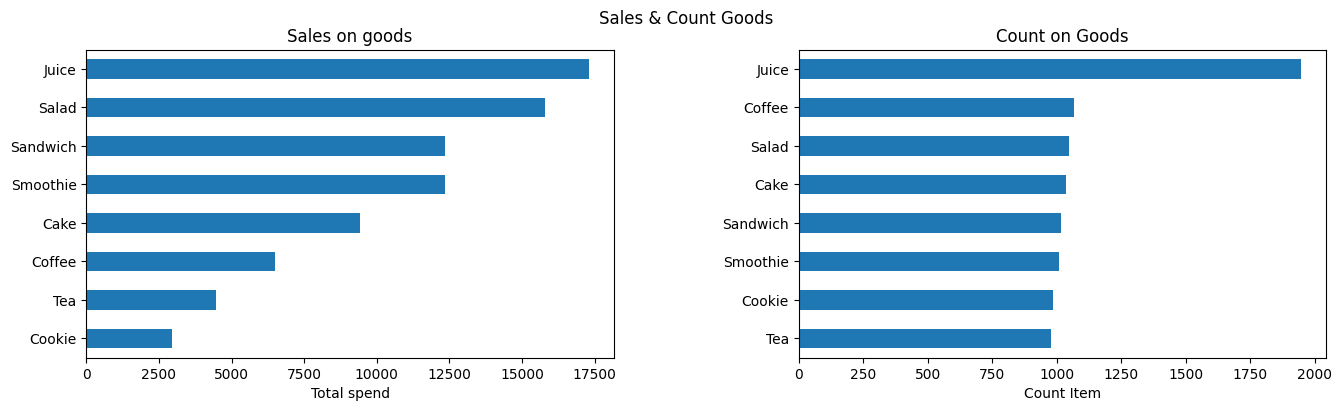

In [ ]:
from matplotlib import axes
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Sales & Count Goods")
plt.subplots_adjust(hspace=0.45, wspace=0.35)
# total_spent per item
ax=axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind = 'barh', ax=ax)
ax.set_title('Sales on goods')
ax.set_xlabel('Total spend')
ax.set_ylabel('')


# count per item
ax = axes[1]   # axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Count on Goods')
ax.set_xlabel('Count Item')
ax.set_ylabel('')
plt.show()

In [ ]:
# df.groupby('item')['total_spent'].sum().sort_values().plot.barh()

# ax.set_title('Count on Goods')
# ax.set_xlabel('Count Item')
# ax.set_ylabel('')
# plt.show()

In [ ]:
# sales on Month
fig = plt.figure(figsize=(8, 3))


month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

df.groupby("month_name")['total_spent'].sum()



,total_spent
month_name,
April,6782.5
August,6756.5
December,6835.5
February,6347.5
January,6894.5
July,6700.5
June,7010.0
March,6931.0
May,6607.5


<Figure size 800x300 with 0 Axes>

In [ ]:
# import calendar    #
# print([calendar.month_name[i] for i in range(1, 13)])

In [ ]:
set(list(df['month_name'].values))

{'April',
 'August',
 'December',
 'February',
 'January',
 'July',
 'June',
 'March',
 'May',
 'November',
 'October',
 'September'}

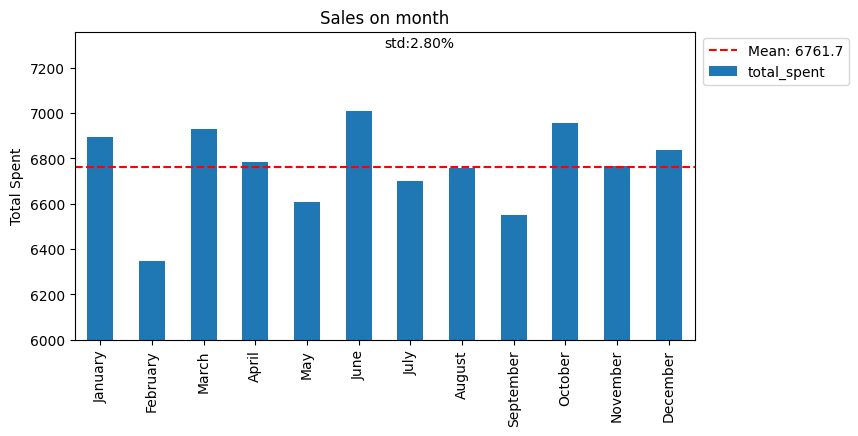

In [ ]:
rev_month = df.groupby("month_name")['total_spent'].sum().reindex([m for m in month_order if m in df['month_name'].unique()])
 # Зміна послідовності

std_pct = (std_value / mean_value)* 100
fig = plt.figure(figsize=(8, 4))
rev_month.plot(kind='bar')
mean_value = rev_month.mean()
std_value = rev_month.std()

plt.axhline(y=mean_value,color='red', linestyle='--', linewidth= 1.5,
            label=f'Mean: {mean_value:.1f}')
plt.ylim(bottom=6000)
plt.text(0.5, 0.95, f"std:{std_pct:.2f}%",transform=plt.gca().transAxes)
plt.title('Sales on month')
plt.xlabel('')
plt.ylabel('Total Spent')
plt.legend(bbox_to_anchor=(1.26, 1), loc = 'upper right')
plt.show()


In [129]:
plt.savefig('cafe_eda.png',dpi=150, bbox_inches= 'tight')

<Figure size 640x480 with 0 Axes>

# Saving a clean CSV

In [136]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# For Tableau better date format: YYYY-MM-DD
try:
    df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
except:
    print('transaction_date was change -(%Y-%m-%d)\n')



# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}")
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

transaction_date was change -(%Y-%m-%d)

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']


In [131]:
try:
    pass
except:
    pass
else:
    pass
finally:
    pass

In [132]:
q = 0
try:
  a = 1 / 1
  q = 1
except Exception as e:
  print("Error:", e)
else:
  print("Спроба ділення")
finally:
  if q:
    print("Виконався try")
  else:
    print("Виконався except")

Спроба ділення
Виконався try


# SUMMARY REPORT

In [162]:
#print(f'Total revenue :        {df['total_spent'].sum():.2f}')
print(f'Total revenue :        {df['total_spent'].sum():>14.2f}')
print(f'Total revenue :        {df['total_spent'].mean():>14.2f}')
print(f'Number of transaction: {len(df):>14,}')
print(f'Average check :        {df['total_spent'].mean():>14,.2f}')
print(f'Median check:          {df['total_spent'].median():>14,.2f}')
print(f'Unique products :      {df['item'].nunique():>14,}')
print(f'Unique locations :     {df['location'].nunique():>14,}')
top_item =df.groupby('item')['total_spent'].sum().idxmax()
print(f'Top profitable product:{top_item:>14}')
# top_pay = df['payment method'].value_counts()
# top_pay.drop('Unknown',errors='ignore').idxmax
top_pay = df.loc[df['payment_method'] != 'Unknown','payment_method'].value_counts().idxmax()

print(f'Unique payment method :{df['payment_method'].nunique():>14,}')
print(f'Top payment method :   {top_pay:>14}')

all_location = df.loc[df['location'] != 'Unknown','location']
print(f'Unique location:       {all_location.nunique():>14}')


Total revenue :              81140.00
Total revenue :                  8.93
Number of transaction:          9,083
Average check :                  8.93
Median check:                    8.00
Unique products :                   8
Unique locations :                  3
Top profitable product:         Juice
Unique payment method :             4
Top payment method :   Digital Wallet
Unique location:                    2


In [ ]:
print(f'Total revenue : {df['total_spent'].sum():.2f}')
print(f'Total revenue : {df['total_spent'].sum():>12.2f}')
print(f'Number of transaction: {}')
print(f'Average check : {}')
print(f'Median check: {}')
print(f'Unique products : {}')
print(f'Unique locations : {}')
print(f'Top profitable product: {}')
print(f'Unique payment method : {}')
print(f'Top payment method : {}')